**Jaundice Detection from Skin and Eye Images for Children & Adults Using AI**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

In [13]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"
IMG_SIZE = 224
CLASSES = ["normal", "jaundice"]

In [14]:
data = []
labels = []

for label, class_name in enumerate(CLASSES):
    class_path = os.path.join(sayem, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(label)
        except:
            pass

X = np.array(data) / 255.0
y = to_categorical(labels, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=labels
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (608, 224, 224, 3)
Test : (152, 224, 224, 3)


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    brightness_range=[0.8,1.2],
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [16]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Phase 1: freeze

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6387 - loss: 0.7588 - val_accuracy: 0.5987 - val_loss: 0.6654
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7051 - loss: 0.6522 - val_accuracy: 0.6974 - val_loss: 0.6090
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7387 - loss: 0.6027 - val_accuracy: 0.7303 - val_loss: 0.6217
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7158 - loss: 0.6222 - val_accuracy: 0.7039 - val_loss: 0.6086
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7312 - loss: 0.5907 - val_accuracy: 0.6974 - val_loss: 0.6072
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7527 - loss: 0.5899 - val_accuracy: 0.6974 - val_loss: 0.6062
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7342 - loss: 0.5991 - val_accuracy: 0.7368 - val_loss: 0.6231
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7384 - loss: 0.5768 - val_accuracy: 0.7303 - val_loss:

FINE-TUNING (Accuracy Improvement)

In [18]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7272 - loss: 0.8060 - val_accuracy: 0.7368 - val_loss: 0.6672
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.6943 - loss: 0.6809 - val_accuracy: 0.7368 - val_loss: 0.6683
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.7322 - loss: 0.5973 - val_accuracy: 0.7368 - val_loss: 0.6686
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7379 - loss: 0.6031 - val_accuracy: 0.7368 - val_loss: 0.6655
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7456 - loss: 0.5782 - val_accuracy: 0.7368 - val_loss: 0.6558
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7365 - loss: 0.5932 - val_accuracy: 0.7368 - val_loss: 0.6503
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7430 - loss: 0.5782 - val_accuracy: 0.7368 - val_loss: 0.6461
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7331 - loss: 0.5775 - val_accuracy: 0.7368 - val_loss:

RESULT GRAPHS (Accuracy & Loss)

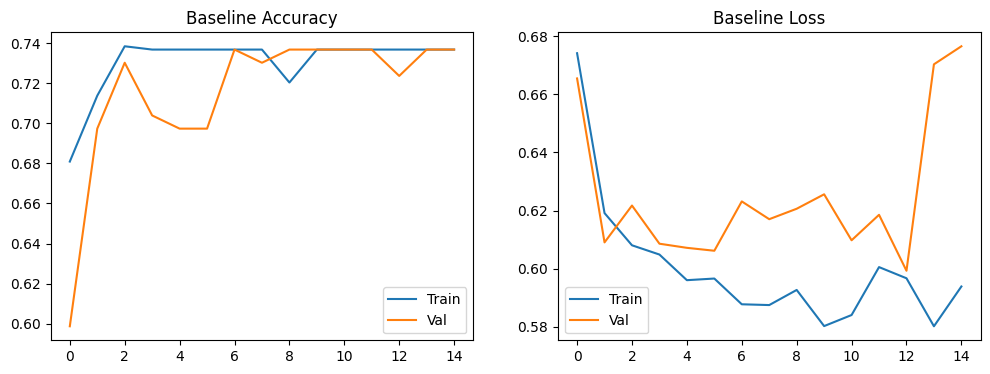

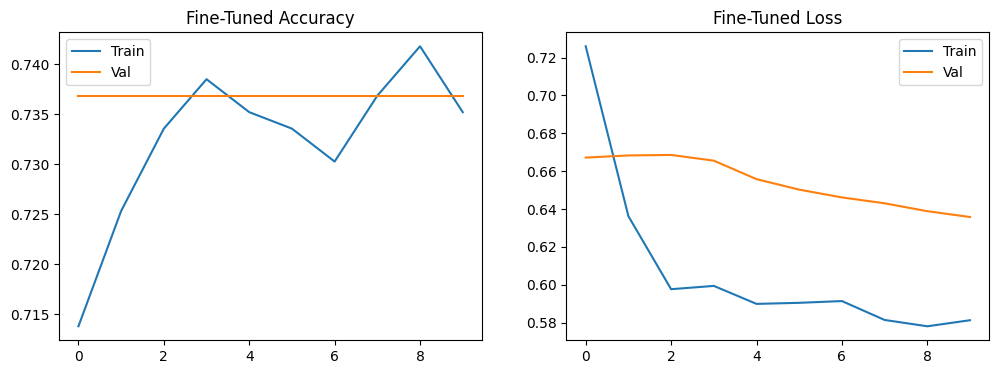

In [19]:
def plot_history(hist, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(history, "Baseline")
plot_history(history_fine, "Fine-Tuned")

Final Evaluation

In [20]:
loss, acc = model.evaluate(X_test, y_test)
print("Final Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6918 - loss: 0.7148
Final Test Accuracy: 0.7368420958518982


SAVE MODEL

In [21]:
model.save("/content/drive/MyDrive/jaundice_model_njn.h5")
print("Model saved successfully")

Model saved successfully


LOAD MODEL (Later use / Demo)

In [22]:
loaded_model = load_model("/content/drive/MyDrive/jaundice_model_njn.h5")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6918 - loss: 0.7148
Loaded Model Accuracy: 0.7368420958518982
